# Análisis de Regresión Lineal de Calidad del Aire



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn import metrics
import sklearn.feature_selection as fs

import warnings
warnings.filterwarnings('ignore')

## 1. Carga y Preprocesamiento de Datos

Cargamos el dataset tratando los valores `-200` como nulos y ajustando el separador decimal.

In [9]:
df = pd.read_csv('AirQuality.csv', sep=';', decimal=',', skipinitialspace=True)
df = df.dropna(axis=1, how='all')
df.replace(-200, np.nan, inplace=True)

print(df.head())
print(df.describe())

         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004  19.00.00     2.0       1292.0     112.0       9.4   
2  10/03/2004  20.00.00     2.2       1402.0      88.0       9.0   
3  10/03/2004  21.00.00     2.2       1376.0      80.0       9.2   
4  10/03/2004  22.00.00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0    131.0        1140.0    114.0        1555.0       1074.0   
3          948.0    172.0        1092.0    122.0        1584.0       1203.0   
4          836.0    131.0        1205.0    116.0        1490.0       1110.0   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  0.7502  
3  11.0  60.0  0.786

Limpiamos los nulos (eliminando NMHC(GT) si es necesario por su alto volumen de nulos) para proceder al análisis.

In [10]:
if 'NMHC(GT)' in df.columns and df['NMHC(GT)'].isnull().mean() > 0.8:
    df.drop(columns=['NMHC(GT)'], inplace=True)
df.dropna(inplace=True)
print("Forma del dataset tras la limpieza:", df.shape)

Forma del dataset tras la limpieza: (6941, 14)


## 2. Regresión Lineal Simple (Exploración Visual)

En primer lugar, consideramos la tarea de predecir el Benceno (`C6H6(GT)`) utilizando el sensor de Titania (`PT08.S2(NMHC)`).

Text(0.5, 1.0, 'Regresión Lineal Simple (Orden 1)')

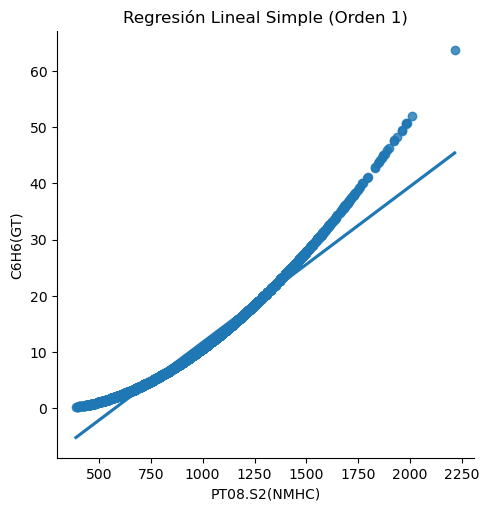

In [11]:
sns.lmplot(data=df, x="PT08.S2(NMHC)", y="C6H6(GT)", order=1)
plt.title("Regresión Lineal Simple (Orden 1)")

Se puede probar fácilmente si se puede obtener un mejor ajuste incluyendo términos de orden superior, como un modelo cuadrático ($order = 2$):

Text(0.5, 1.0, 'Regresión Lineal Simple (Orden 2)')

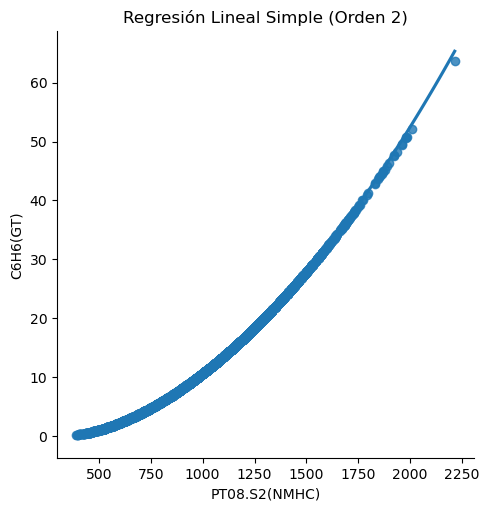

In [12]:
sns.lmplot(data=df, x="PT08.S2(NMHC)", y="C6H6(GT)", order=2)
plt.title("Regresión Lineal Simple (Orden 2)")

## 3. Entrenamiento de Regresión Lineal Múltiple

Ahora utilizamos todas las variables numéricas disponibles para intentar predecir el objetivo.

In [13]:
features = ['CO(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
target = 'C6H6(GT)'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regr = LinearRegression()
regr.fit(X_train, y_train)

print("Coeff and intercept:", regr.coef_, regr.intercept_)

Coeff and intercept: [ 7.40075755e-01  3.62229747e-04  2.47163782e-02  3.17651022e-03
  2.59064307e-03 -1.10680315e-02  1.17928635e-03 -3.24826840e-04
 -7.76243644e-02 -2.67177003e-02  7.98288882e-01] -16.273513692111795


## 4. Evaluación del Modelo

Ejecutamos la predicción sobre los datos de test y evaluamos mediante MSE, $R^2$ y varianza.

In [14]:
y_pred = regr.predict(X_test)
print("MSE:", metrics.mean_squared_error(y_pred, y_test))
print("R^2:", metrics.r2_score(y_pred, y_test))
print("var:", y_pred.var(), y_test.var())

MSE: 1.0183081194070824
R^2: 0.9800537576825888
var: 51.05262952301537 52.282618774936


## 5. Regularización con Lasso

Intentamos construir un modelo disperso utilizando Lasso para descartar factores no informativos.

In [15]:
regr_lasso = Lasso(alpha=0.3)
regr_lasso.fit(X_train, y_train)
y_pred_lasso = regr_lasso.predict(X_test)

print("MSE (Lasso):", metrics.mean_squared_error(y_pred_lasso, y_test))
print("R^2 (Lasso):", metrics.r2_score(y_pred_lasso, y_test))
print("Coeff and intercept (Lasso):", regr_lasso.coef_, regr_lasso.intercept_)

MSE (Lasso): 1.1692419098349276
R^2 (Lasso): 0.9770459847834021
Coeff and intercept (Lasso): [ 0.          0.00139327  0.02734995  0.00439613  0.0031915  -0.00938037
  0.00126444 -0.0004866  -0.03675251 -0.00842775 -0.        ] -20.110446510013986


Variables ordenadas de menos a más importantes según los coeficientes de Lasso:

In [16]:
ind = np.argsort(np.abs(regr_lasso.coef_))
print("(Variables ordenadas por importancia):")
print(X.columns[ind])

(Variables ordenadas por importancia):
Index(['CO(GT)', 'AH', 'PT08.S5(O3)', 'PT08.S4(NO2)', 'PT08.S1(CO)',
       'PT08.S3(NOx)', 'NOx(GT)', 'RH', 'NO2(GT)', 'PT08.S2(NMHC)', 'T'],
      dtype='object')


## 6. Visualización de Predicciones

Visualizamos las respuestas reales vs las predichas.

Text(0.5, 1.0, 'Valores Reales vs Predichos')

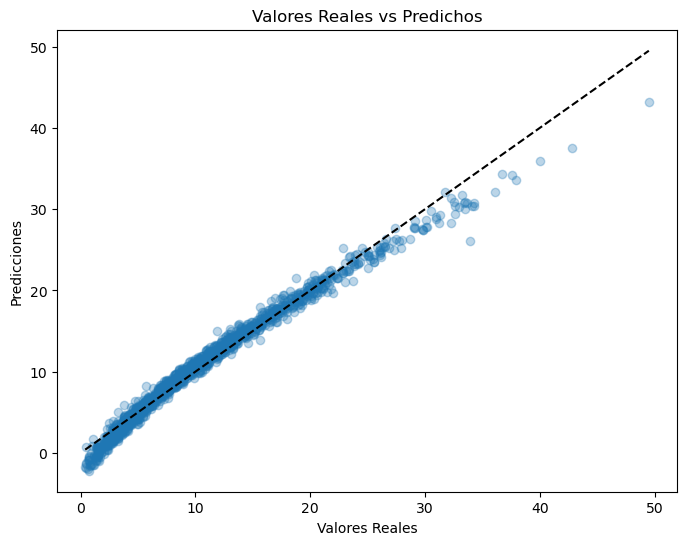

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
min_val, max_val = min(y_test), max(y_test)
plt.plot([min_val, max_val], [min_val, max_val], "--k")
plt.axis("tight")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predichos")

## 7. Selección de Características Avanzada

Podemos seleccionar las mejores k=5 características utilizando `SelectKBest`.

In [18]:
selector = fs.SelectKBest(score_func=fs.f_regression, k=5)
X_best = selector.fit_transform(X_train, y_train)
print("Variables seleccionadas:")
print(X.columns[selector.get_support()].tolist())

Variables seleccionadas:
['CO(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
